In [112]:
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

In [113]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1D dataset**

In [114]:
## Reading file into a numpy array
x_train,t_train = np.loadtxt("/content/drive/MyDrive/1d_team_4_train.txt", unpack=True)
x_dev,t_dev = np.loadtxt("/content/drive/MyDrive/1d_team_4_dev.txt", unpack=True)

In [115]:
N = 200   # size of the training data
M = 5     # model complexity

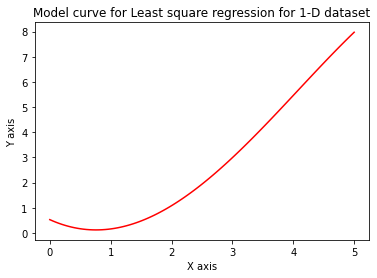

In [116]:
# Least square regression for 1-D dataset
a = np.zeros([M,M])
c = np.zeros(M)

for i in range(M):
  for j in range(M):
    for n in range(N):
      a[i,j] += x_train[n]**(i+j)

for i in range(M):
  for n in range(N):
    c[i] += t_train[n]*(x_train[n]**i)

w = np.linalg.inv(a)@c

# model
def y1(x):
  sum = 0
  for i in range(M):
    sum += w[i]*(x**i)        
  return sum

x1 = np.linspace(0,5,100)

# plotting
plt.title("Model curve for Least square regression for 1-D dataset")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.plot(x1, y1(x1), color ="red")
plt.show()

## Obs : 9-16 downwards

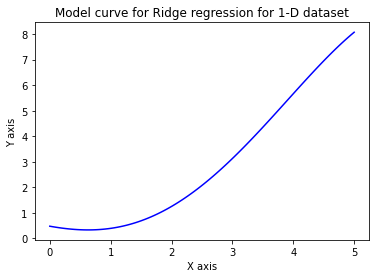

In [117]:
# Ridge regression for 1-D dataset
phi = np.zeros([N,M])
lam = math.exp(0)

for i in range(N):
  for j in range(M):
    phi[i,j] = x_train[i]**j

w = np.linalg.inv(np.add(phi.T@phi,lam*np.eye(M)))@(phi.T)@(t_train[:N])

# model
def y2(x):
  sum = 0
  for i in range(M):
    sum += w[i]*(x**i)        
  return sum + (lam/2)*np.sum(w**2)

x2 = np.linspace(0,5,100)

# plotting
plt.title("Model curve for Ridge regression for 1-D dataset")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.plot(x2, y2(x2), color ="blue")
plt.show()

**2D dataset**

In [118]:
## Reading file into a numpy array
x1_train,x2_train,t_train = np.loadtxt("/content/drive/MyDrive/2d_team_4_train.txt", unpack=True)
x1_dev,x2_dev,t_dev = np.loadtxt("/content/drive/MyDrive/2d_team_4_dev.txt", unpack=True)

In [119]:
N = 1000   # size of the training data
M = 5      # model complexity

TypeError: ignored

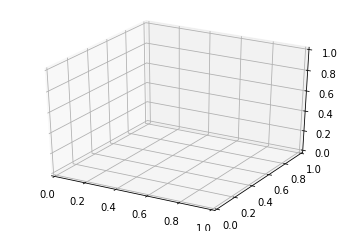

In [120]:
# Least square regression for 2-D dataset
phi = np.zeros([N,M])

for i in range(N):
  for j in range(M):
    phi[i,j] = math.sqrt(x1_train[i]**2 + x2_train[i]**2)**j

w = np.linalg.inv(phi.T@phi)@(phi.T)@(t_train[:N])

# model
def y3(x,y):
  sum = 0
  for i in range(M):
    sum += w[i]*(math.sqrt((x**2)+(y**2))**i)      
  return sum

fig = plt.figure()
 
# syntax for 3-D projection
ax = plt.axes(projection ='3d')
 
# defining all 3 axes
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
z = y3(x,y)

# plotting
ax.plot3D(x, y, z, 'green')
ax.set_title('Model curve for Least square regression for 2-D dataset')
plt.show()

In [ ]:
# Ridge regression for 2-D dataset
phi = np.zeros([N,M])
lam = 0

for i in range(N):
  for j in range(M):
    phi[i,j] = math.sqrt((x1_train[i]**2)+(x2_train[i]**2))**j

w = np.linalg.inv(np.add(phi.T@phi,lam*np.eye(M)))@(phi.T)@(t_train[:N])

# model
def y4(a,b):
  sum = 0
  for i in range(M):
    sum += w[i]*(math.sqrt((a**2)+(b**2))**i)        
  return sum + (lam/2)*np.sum(w**2)

fig = plt.figure()
 
# syntax for 3-D projection
ax = plt.axes(projection ='3d')

x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
z = y4(x,y)

# plotting
ax.plot3D(x, y, z, 'purple')
ax.set_title('Model curve for Ridge regression for 2-D dataset')
plt.show()